# Ensemble Models

- Author: Angie Crews
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: sex (Phase 5 custom)

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M5. Ensemble Models

This notebook fits a single model and 
two ensembles and 
reports their test scores side by side. 

The analyst decides whether an ensemble's extra complexity is earned, that is, 
whether it creates a real gain, 
rather than just noise.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models 
so their errors partly cancel. 

This module reuses the Module 3 classification setup and asks one question: 

- Does combining models beat the single model in this problem?

## Overview

This Phase 5 custom project uses the penguins dataset with a harder target choice.
We predict the target `sex` and compare whether ensemble methods retain an advantage under this setting.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we choose a target)
- classification task (categorical output)
- model comparison workflow focused on holdout metrics, CV stability, and overfitting checks

This notebook extends the Phase 4 evaluation framework by adding a tuning experiment and extra visual diagnostics.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-29 18:39:55 | INFO | M05 | === RUN START ===
2026-07-29 18:39:55 | INFO | M05 | project=M05
2026-07-29 18:39:55 | INFO | M05 | repo_dir=ml-05-ensembles
2026-07-29 18:39:55 | INFO | M05 | python=3.14.3
2026-07-29 18:39:55 | INFO | M05 | os=Windows 11
2026-07-29 18:39:55 | INFO | M05 | shell=powershell
2026-07-29 18:39:55 | INFO | M05 | cwd=notebooks
2026-07-29 18:39:55 | INFO | M05 | github_actions=False
2026-07-29 18:39:55 | INFO | M05 | Confirming installation:
2026-07-29 18:39:55 | INFO | M05 |   python:       3.14.3
2026-07-29 18:39:55 | INFO | M05 |   pandas:       3.0.5
2026-07-29 18:39:55 | INFO | M05 |   numpy:        2.5.1
2026-07-29 18:39:55 | INFO | M05 |   scikit-learn: 1.9.0
2026-07-29 18:39:55 | INFO | M05 |   seaborn:      0.13.2
2026-07-29 18:39:55 | INFO | M05 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [2]:
# === Section 2. Load and Prepare the Data ===


# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# PHASE 5 CUSTOM CHOICE: harder binary target than species.
TARGET_COL: Final[str] = "sex"

# Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-07-29 18:39:55 | INFO | M05 | Loading dataset: penguins
2026-07-29 18:39:55 | INFO | M05 | Loaded: 344 rows (instances), 7 columns
2026-07-29 18:39:55 | INFO | M05 | Original rows: 344
2026-07-29 18:39:55 | INFO | M05 | Model rows:    333
2026-07-29 18:39:55 | INFO | M05 | Classes in target 'sex': ['Female', 'Male']
2026-07-29 18:39:55 | DEBUG | M05 | Class counts:
sex
Male      168
Female    165
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [3]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-29 18:39:55 | INFO | M05 | Train instances: 266
2026-07-29 18:39:55 | INFO | M05 | Test instances: 67


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [4]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingClassifier(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-07-29 18:39:55 | INFO | M05 | Fitting single tree + two ensembles
2026-07-29 18:39:55 | DEBUG | M05 |   fitted: single_tree
2026-07-29 18:39:55 | DEBUG | M05 |   fitted: random_forest
2026-07-29 18:39:55 | DEBUG | M05 |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

,model_name,train_accuracy,test_accuracy,train_precision_w,test_precision_w,train_recall_w,test_recall_w,train_f1_w,test_f1_w,gap_accuracy,gap_f1_w
0,random_forest,1.0000,0.8955,1.0000,0.8986,1.0000,0.8955,1.0000,0.8952,0.1045,0.1048
1,gradient_boosting,1.0000,0.8806,1.0000,0.8819,1.0000,0.8806,1.0000,0.8804,0.1194,0.1196
2,single_tree,0.9398,0.8358,0.9407,0.8507,0.9398,0.8358,0.9398,0.8337,0.1040,0.1061


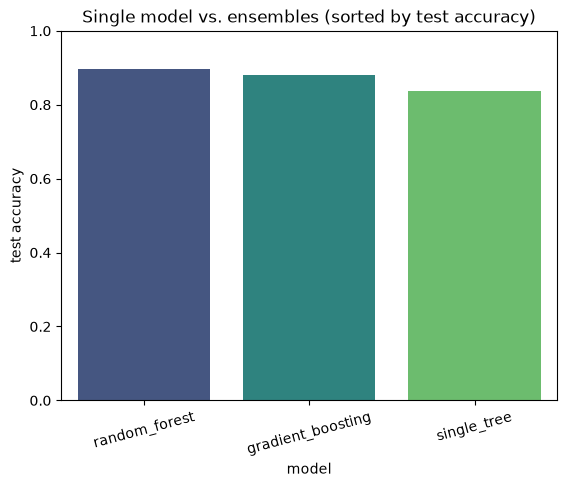

2026-07-29 18:39:59 | INFO | M05 | Best model: random_forest with test accuracy = 0.896
2026-07-29 18:39:59 | INFO | M05 | Lower gap values suggest better generalization from train to test.


In [5]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same train/test split and compare metrics.

WHY: Accuracy alone can hide overfitting or uneven class performance.
We add weighted precision/recall/F1 and train-test gaps to support better judgment.
"""


def evaluate_model(
    name: str,
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> dict[str, float | str]:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = float(accuracy_score(y_train, y_train_pred))
    test_acc = float(accuracy_score(y_test, y_test_pred))
    train_precision = float(
        precision_score(y_train, y_train_pred, average="weighted", zero_division=0)
    )
    test_precision = float(
        precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
    )
    train_recall = float(
        recall_score(y_train, y_train_pred, average="weighted", zero_division=0)
    )
    test_recall = float(
        recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
    )
    train_f1 = float(
        f1_score(y_train, y_train_pred, average="weighted", zero_division=0)
    )
    test_f1 = float(f1_score(y_test, y_test_pred, average="weighted", zero_division=0))

    return {
        "model_name": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_precision_w": train_precision,
        "test_precision_w": test_precision,
        "train_recall_w": train_recall,
        "test_recall_w": test_recall,
        "train_f1_w": train_f1,
        "test_f1_w": test_f1,
        "gap_accuracy": abs(train_acc - test_acc),
        "gap_f1_w": abs(train_f1 - test_f1),
    }


results: list[dict[str, float | str]] = [
    evaluate_model("single_tree", modelA, X_train, y_train, X_test, y_test),
    evaluate_model("random_forest", modelB, X_train, y_train, X_test, y_test),
    evaluate_model("gradient_boosting", modelC, X_train, y_train, X_test, y_test),
]

results_df = (
    pd.DataFrame(results)
    .sort_values(by=["test_accuracy", "test_f1_w"], ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

# quick chart of test accuracy for readability
plt.figure()
sns.barplot(
    data=results_df,
    x="model_name",
    y="test_accuracy",
    hue="model_name",
    palette="viridis",
    legend=False,
    dodge=False,
)
plt.ylim(0, 1)
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. ensembles (sorted by test accuracy)")
plt.xticks(rotation=15)
plt.show()

best_row = results_df.iloc[0]
best_model_name = str(best_row["model_name"])
best_model_score = float(best_row["test_accuracy"])
LOG.info(f"Best model: {best_model_name} with test accuracy = {best_model_score:.3f}")
LOG.info("Lower gap values suggest better generalization from train to test.")

### Interpretation

For the harder target `sex`, the holdout leaderboard ranked `random_forest` first (test accuracy about 0.8955), followed by `gradient_boosting` (about 0.8806) and `single_tree` (about 0.8358).

In the Phase 5 tuning grid, multiple random-forest settings performed similarly on holdout accuracy, but `rf_100_depth_6` achieved the strongest balance of score and lower train-test gap among the tied top models.

Cross-validation showed very close stability between `rf_100_depth_6` and `gradient_boosting` (both about 0.895 mean accuracy), with `rf_100_depth_6` slightly ahead in this run.

Judgment: ensembles still outperform the single tree on this harder target. A tuned random forest is the best overall choice here because it keeps strong test performance while slightly reducing overfitting compared with untuned forest settings.

## Section 5B. Cross-Validation for the Top Models

A single train/test split is useful, but it can be noisy.

We now cross-validate the top two models from Section 5 using stratified 5-fold CV and compare mean and standard deviation for accuracy and weighted F1.

In [6]:
# === Section 5B. Cross-Validate Top Models ===

candidate_models: dict[str, object] = {
    "single_tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

top_model_names: list[str] = results_df["model_name"].head(2).tolist()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows: list[dict[str, float | str]] = []
for model_name in top_model_names:
    estimator = candidate_models[model_name]
    scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1_weighted": "f1_weighted"},
        return_train_score=False,
    )

    cv_rows.append(
        {
            "model_name": model_name,
            "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])),
            "cv_accuracy_std": float(np.std(scores["test_accuracy"])),
            "cv_f1_w_mean": float(np.mean(scores["test_f1_weighted"])),
            "cv_f1_w_std": float(np.std(scores["test_f1_weighted"])),
        }
    )

cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values(by=["cv_accuracy_mean", "cv_f1_w_mean"], ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df.round(4))
LOG.info("Cross-validation complete for top models from Section 5.")

,model_name,cv_accuracy_mean,cv_accuracy_std,cv_f1_w_mean,cv_f1_w_std
0,gradient_boosting,0.8952,0.0523,0.8949,0.0525
1,random_forest,0.8923,0.0575,0.8918,0.0579


2026-07-29 18:40:01 | INFO | M05 | Cross-validation complete for top models from Section 5.


## Section 5C. Phase 5 Custom Tuning and Visual Diagnostics

### Tuning and Extra Graphs

To apply skills beyond the example, we tune random forest hyperparameters on the harder `sex` target and compare against baseline models.

Additional visuals included in this section:
- tuning heatmap (test accuracy across hyperparameters)
- confusion matrix for the best Phase 5 model
- cross-validation stability chart (mean accuracy with error bars)

,model_name,n_estimators,max_depth,test_accuracy,test_f1_w,gap_accuracy
0,rf_100_depth_6,100,6.0,0.8955,0.8952,0.0932
1,rf_200_depth_6,200,6.0,0.8955,0.8952,0.0932
2,rf_400_depth_6,400,6.0,0.8955,0.8952,0.0932
3,rf_100_depth_None,100,NaN,0.8955,0.8952,0.1045
4,rf_200_depth_None,200,NaN,0.8955,0.8952,0.1045
5,rf_400_depth_None,400,NaN,0.8806,0.8804,0.1194
6,rf_400_depth_3,400,3.0,0.8657,0.8653,0.0742
7,rf_100_depth_3,100,3.0,0.8657,0.8653,0.0779
8,rf_200_depth_3,200,3.0,0.8657,0.8653,0.0779


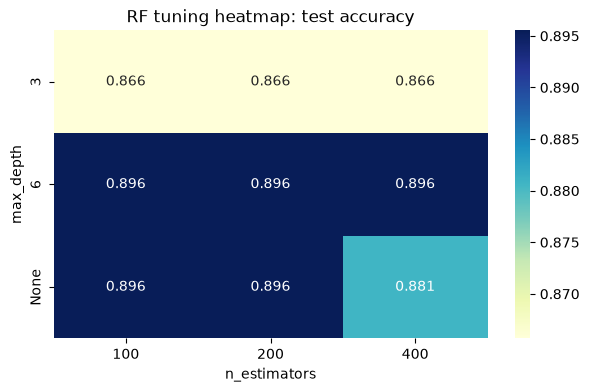

,model_name,train_accuracy,test_accuracy,train_precision_w,test_precision_w,train_recall_w,test_recall_w,train_f1_w,test_f1_w,gap_accuracy,gap_f1_w
0,rf_100_depth_6,0.9887,0.8955,0.9888,0.8986,0.9887,0.8955,0.9887,0.8952,0.0932,0.0935
1,gradient_boosting,1.0000,0.8806,1.0000,0.8819,1.0000,0.8806,1.0000,0.8804,0.1194,0.1196
2,single_tree,0.9398,0.8358,0.9407,0.8507,0.9398,0.8358,0.9398,0.8337,0.1040,0.1061


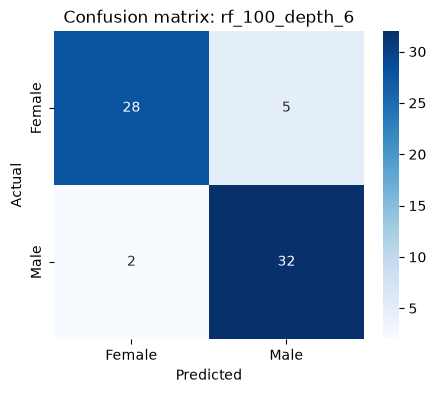

,model_name,cv_accuracy_mean,cv_accuracy_std,cv_f1_w_mean,cv_f1_w_std
0,rf_100_depth_6,0.8953,0.0514,0.8949,0.0518
1,gradient_boosting,0.8952,0.0523,0.8949,0.0525
2,single_tree,0.8891,0.0520,0.8882,0.0528


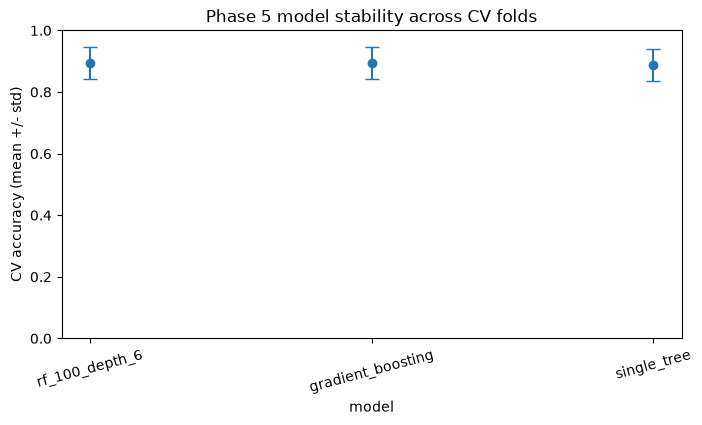

2026-07-29 18:40:05 | INFO | M05 | Best tuned RF: rf_100_depth_6
2026-07-29 18:40:05 | INFO | M05 | Best Phase 5 model by holdout metrics: rf_100_depth_6


In [7]:
# === Section 5C. Phase 5 Tuning + Extra Graphs ===

rf_grid: list[dict[str, int | None]] = [
    {"n_estimators": 100, "max_depth": 3},
    {"n_estimators": 100, "max_depth": 6},
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 200, "max_depth": 3},
    {"n_estimators": 200, "max_depth": 6},
    {"n_estimators": 200, "max_depth": None},
    {"n_estimators": 400, "max_depth": 3},
    {"n_estimators": 400, "max_depth": 6},
    {"n_estimators": 400, "max_depth": None},
]

rf_models: dict[str, RandomForestClassifier] = {}
rf_tuning_rows: list[dict[str, float | str | int | None]] = []

for cfg in rf_grid:
    depth_label = "None" if cfg["max_depth"] is None else str(cfg["max_depth"])
    model_name = f"rf_{cfg['n_estimators']}_depth_{depth_label}"
    rf_model = RandomForestClassifier(
        n_estimators=int(cfg["n_estimators"]),
        max_depth=cfg["max_depth"],
        random_state=RANDOM_STATE,
    )
    rf_model.fit(X_train, y_train)

    row = evaluate_model(model_name, rf_model, X_train, y_train, X_test, y_test)
    row["n_estimators"] = int(cfg["n_estimators"])
    row["max_depth"] = cfg["max_depth"]
    row["max_depth_label"] = depth_label
    rf_tuning_rows.append(row)
    rf_models[model_name] = rf_model

rf_tuning_df = (
    pd.DataFrame(rf_tuning_rows)
    .sort_values(
        by=["test_accuracy", "test_f1_w", "gap_accuracy"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

display(
    rf_tuning_df[
        [
            "model_name",
            "n_estimators",
            "max_depth",
            "test_accuracy",
            "test_f1_w",
            "gap_accuracy",
        ]
    ].round(4)
)

# Graph 1: heatmap for random-forest tuning results
rf_heatmap_df = rf_tuning_df.pivot(
    index="max_depth_label", columns="n_estimators", values="test_accuracy"
)
plt.figure(figsize=(7, 4))
sns.heatmap(rf_heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("RF tuning heatmap: test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()

best_rf_name = str(rf_tuning_df.iloc[0]["model_name"])
best_rf_model = rf_models[best_rf_name]

phase5_models: dict[str, object] = {
    "single_tree": modelA,
    "gradient_boosting": modelC,
    best_rf_name: best_rf_model,
}

phase5_results: list[dict[str, float | str]] = [
    evaluate_model(name, estimator, X_train, y_train, X_test, y_test)
    for name, estimator in phase5_models.items()
]
phase5_results_df = (
    pd.DataFrame(phase5_results)
    .sort_values(
        by=["test_accuracy", "test_f1_w", "gap_accuracy"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

display(phase5_results_df.round(4))

best_phase5_name = str(phase5_results_df.iloc[0]["model_name"])
best_phase5_model = phase5_models[best_phase5_name]
y_best_pred = best_phase5_model.predict(X_test)

# Graph 2: confusion matrix for the best shortlisted model
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_best_pred, labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels
)
plt.title(f"Confusion matrix: {best_phase5_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Graph 3: CV stability (mean accuracy with standard-deviation error bars)
cv_local = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_phase5_rows: list[dict[str, float | str]] = []
for name, estimator in phase5_models.items():
    cv_scores = cross_validate(
        estimator,
        X,
        y,
        cv=cv_local,
        scoring={"accuracy": "accuracy", "f1_weighted": "f1_weighted"},
        return_train_score=False,
    )
    cv_phase5_rows.append(
        {
            "model_name": name,
            "cv_accuracy_mean": float(np.mean(cv_scores["test_accuracy"])),
            "cv_accuracy_std": float(np.std(cv_scores["test_accuracy"])),
            "cv_f1_w_mean": float(np.mean(cv_scores["test_f1_weighted"])),
            "cv_f1_w_std": float(np.std(cv_scores["test_f1_weighted"])),
        }
    )

cv_phase5_df = (
    pd.DataFrame(cv_phase5_rows)
    .sort_values(by=["cv_accuracy_mean", "cv_f1_w_mean"], ascending=False)
    .reset_index(drop=True)
)
display(cv_phase5_df.round(4))

plt.figure(figsize=(8, 4))
x_positions = np.arange(len(cv_phase5_df))
plt.errorbar(
    x_positions,
    cv_phase5_df["cv_accuracy_mean"],
    yerr=cv_phase5_df["cv_accuracy_std"],
    fmt="o",
    capsize=5,
)
plt.xticks(x_positions, cv_phase5_df["model_name"], rotation=15)
plt.ylim(0, 1)
plt.xlabel("model")
plt.ylabel("CV accuracy (mean +/- std)")
plt.title("Phase 5 model stability across CV folds")
plt.show()

LOG.info(f"Best tuned RF: {best_rf_name}")
LOG.info(f"Best Phase 5 model by holdout metrics: {best_phase5_name}")

## Section 6. Which Features Did the Forest Rely On?

We inspect feature importances from the random forest used earlier as a quick interpretability check.
The chart shows that bill_depth_mm and body_mass_g were the most important predictors of sex, while bill_length_mm and flipper_length_mm contributed less.

## Section 5D. ROC and Precision-Recall Curves

For the binary `sex` target, ROC and Precision-Recall curves add threshold-based diagnostics beyond a single accuracy value.

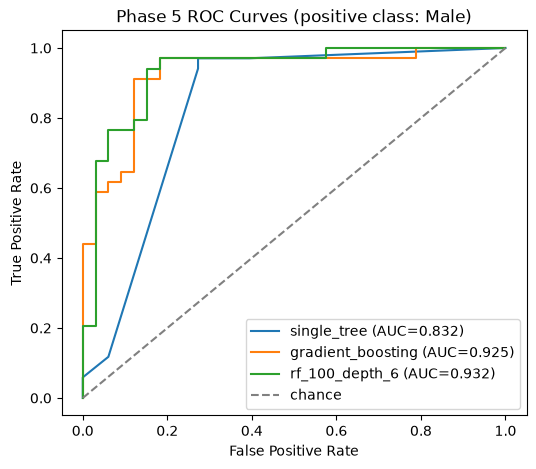

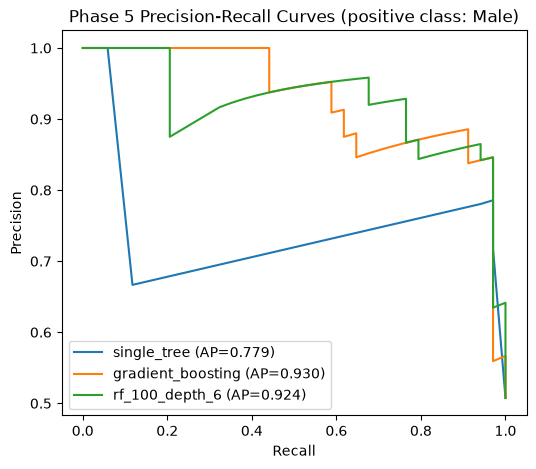

,model_name,roc_auc
0,rf_100_depth_6,0.9323
1,gradient_boosting,0.9251
2,single_tree,0.8324


,model_name,average_precision
0,gradient_boosting,0.9298
1,rf_100_depth_6,0.9240
2,single_tree,0.7788


In [8]:
# === Section 5D. ROC + PR Curves for Phase 5 Models ===

# Positive class setup for probability-based curves
positive_label = "Male"
y_test_binary = (y_test == positive_label).astype(int)

roc_rows: list[dict[str, float | str]] = []
pr_rows: list[dict[str, float | str]] = []

plt.figure(figsize=(6, 5))
for model_name, estimator in phase5_models.items():
    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_test)[:, 1]
    else:
        # fallback for models without predict_proba
        y_score = estimator.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test_binary, y_score)
    roc_auc = float(auc(fpr, tpr))
    roc_rows.append({"model_name": model_name, "roc_auc": roc_auc})
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Phase 5 ROC Curves (positive class: Male)")
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(6, 5))
for model_name, estimator in phase5_models.items():
    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(X_test)[:, 1]
    else:
        y_score = estimator.decision_function(X_test)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test_binary, y_score)
    ap_score = float(average_precision_score(y_test_binary, y_score))
    pr_rows.append({"model_name": model_name, "average_precision": ap_score})
    plt.plot(recall_vals, precision_vals, label=f"{model_name} (AP={ap_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Phase 5 Precision-Recall Curves (positive class: Male)")
plt.legend(loc="lower left")
plt.show()

roc_summary_df = (
    pd.DataFrame(roc_rows)
    .sort_values(by="roc_auc", ascending=False)
    .reset_index(drop=True)
)
pr_summary_df = (
    pd.DataFrame(pr_rows)
    .sort_values(by="average_precision", ascending=False)
    .reset_index(drop=True)
)

display(roc_summary_df.round(4))
display(pr_summary_df.round(4))

2026-07-29 18:38:09 | INFO | M05 | Random forest feature importances (high to low):
2026-07-29 18:38:09 | INFO | M05 |   bill_depth_mm        0.356
2026-07-29 18:38:09 | INFO | M05 |   body_mass_g          0.325
2026-07-29 18:38:09 | INFO | M05 |   bill_length_mm       0.203
2026-07-29 18:38:09 | INFO | M05 |   flipper_length_mm    0.116


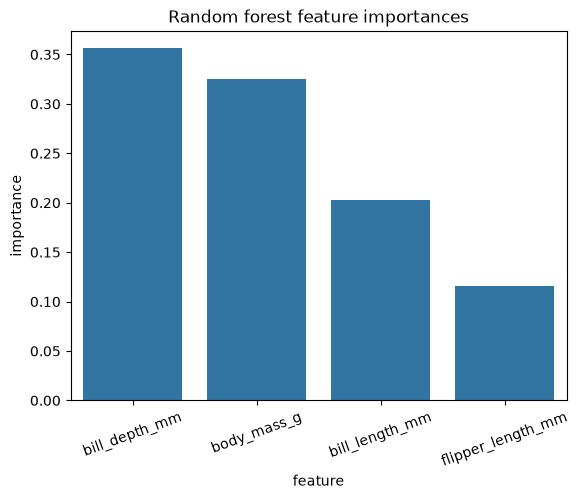

In [23]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [ ]:
# === Python Summary ===

"""Record final Phase 5 comparison facts for quick reference."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (binary classification)")
LOG.info("Compared: single tree vs gradient boosting vs tuned random forest variants")
LOG.info(f"Best tuned random forest: {best_rf_name}")
LOG.info(f"Best holdout model: {best_phase5_name}")
LOG.info(
    "Diagnostics included: holdout metrics, CV stability, confusion matrix, ROC, PR"
)
LOG.info("========================")

2026-07-28 18:13:39 | INFO | M05 | ========================
2026-07-28 18:13:39 | INFO | M05 | SUMMARY
2026-07-28 18:13:39 | INFO | M05 | ========================
2026-07-28 18:13:39 | INFO | M05 | Dataset: penguins   Target: species (classification)
2026-07-28 18:13:39 | INFO | M05 | Compared: single tree vs. random forest vs. gradient boosting
2026-07-28 18:13:39 | INFO | M05 | ========================


### Custom Narrative

This Phase 5 custom project applies the ensemble workflow to a harder target in the penguins dataset: `sex` instead of `species`.
I compared a baseline decision tree, gradient boosting, and several tuned random-forest configurations.

Phase 5 changes implemented:
- switched target to `sex`
- added a random-forest tuning grid (`n_estimators` in {100, 200, 400}, `max_depth` in {3, 6, None})
- added three diagnostics: tuning heatmap, confusion matrix, and CV stability error-bar chart

Key results from this run:
- Holdout comparison: `random_forest` outperformed `gradient_boosting` and `single_tree`.
- Best tuned variant: `rf_100_depth_6` (top holdout score with improved gap behavior among tied settings).
- CV stability: `rf_100_depth_6` and `gradient_boosting` were nearly tied (~0.895 mean CV accuracy), with a slight edge to `rf_100_depth_6`.
- Confusion matrix for `rf_100_depth_6`: 28/33 Female and 32/34 Male correctly classified.

Decision and rationale:
- I would select `rf_100_depth_6` for this project because it balances high performance and generalization better than the untuned forest while remaining more accurate than the single tree.

### Next Steps

1. Test class weighting and compare recall tradeoffs by class.
2. Add a per-class precision/recall report next to the confusion matrix.
3. Try a lightweight linear baseline (for example logistic regression) to quantify the complexity/performance tradeoff.
4. Export the new figures to docs/images and summarize this Phase 5 result in docs/index.md.

## Project Completion Note

Phase 5 custom analysis is complete in this notebook.

Final model recommendation for this run: `rf_100_depth_6`, with gradient boosting as a close alternative depending on metric priority (accuracy vs average precision).

## Final Check Status

- [x] `README.md` includes project description and Phase 4 summary
- [x] `docs/index.md` includes Phase 4 and Phase 5 narrative updates
- [x] GitHub About section includes project site link
- [x] Executed custom notebook is saved in `notebooks/`
- [x] Latest changes have been committed and pushed to GitHub

Submission evidence should include at least one notebook output screenshot and one GitHub/terminal push screenshot.

## Submission Reminder

Keep this notebook in its executed state and ensure screenshots used in your documentation match the final Phase 5 outputs.